In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [2]:
!jupyter nbconvert --to python Divar_cleaning.ipynb


[NbConvertApp] Converting notebook Divar_cleaning.ipynb to python
[NbConvertApp] Writing 6198 bytes to Divar_cleaning.py


In [3]:
import Divar_cleaning as dclean

In [4]:
data = pd.read_csv('sampled_data.csv',encoding = 'utf-8', engine='python')

In [5]:
#Cleaned Data as df

df = dclean.cleaning_data(data)

# after cleaning using cleaning_data function, there is no boolean value since thay have been converted to int
# So, we have numeric, categorical and text columns

In [6]:
df.shape

(125960, 47)

<a id = "rf"></a>
<h1  style="color:blue; font-family:Nazanin;" dir="rtl">1- پیش‌پردازش </h1>

<p style="font-family:Nazanin; font-size:140%; text-align:right;" dir="rtl">
  متغیرهای موثر در قیمت آگهی‌ها را با تحلیل داده انتخاب کنید. متغیرهای انتخاب شده را به ساختار مناسب برای مدلسازی تبدیل کنید. به عنوان نمونه اگر نیاز به نرمال‌سازی و تغییر متغیرهای دیگر وجود دارد اعمال کنید. اگر مقادیر متناقض، ناموجود یا پرت در هر یک از متغیرها ممکن است مخل مدلسازی شود درباره آن شیوه درست مواجهه با آن تصمیم‌گیری کنید. 
</p>

# In this section, we only need to work on Numerical and Categorical columns (not text) 

In [7]:
numeric_cols, categorical_cols, bool_cols, text_cols = dclean.detect_column_types(df)

# Making X and Y ready

In [8]:
df_pre = pd.DataFrame()

for col in numeric_cols:
    df_pre[col] = df[col]

#Using LabelEncoding
for col in categorical_cols:    
    encoder = LabelEncoder()
    df_pre[col] = df[col]
    df_pre[f'{col}_encoded'] = encoder.fit_transform(df[col])

#Using OneHotEncoding
# for col in categorical_cols:    
#     encoder = OneHotEncoder(sparse_output=False)
#     df_pre[col] = df[col]
#     df_pre[f'{col}_encoded'] = encoder.fit_transform(df[col])

for col in categorical_cols:
    le = LabelEncoder()
    df_pre[col] = df[col]
    df_pre[f'{col}_encoded'] = le.fit_transform(df[col])

    
target_col = 'value_rent_or_price'

y = df_pre[target_col]


# Preparing X for Models requir Encoding (All fuatures should be numeric) >>> Regression, KNN, SVM, Neural Network

In [9]:
cat_encoded_cols = [c + '_encoded' for c in categorical_cols]
X_Enc = df_pre [numeric_cols + cat_encoded_cols].drop(columns = target_col)

# Makeing X_Enc Standard

In [10]:
scaler = StandardScaler()
X_Enc = scaler.fit_transform(X_Enc)


# Preparing X for Models NOT requir Encoding >>> DesicionTree, RandomForest

In [11]:
X_Tree = df_pre[numeric_cols + categorical_cols].drop(columns = target_col)

In [12]:
print("X_Enc shape:", X_Enc.shape)
print("X_Tree shape:", X_Tree.shape)
print("Y shape:", y.shape)


X_Enc shape: (125960, 44)
X_Tree shape: (125960, 44)
Y shape: (125960,)


# Creating Train, Validation and Test Dataset (Linear Models) - For X_Enc

In [13]:
# Creating a testing dataset of size 0.2 times the whole dataset  
X_train, X_test, y_train, y_test = train_test_split( X_Enc, y, 
                                                    test_size = 0.2, 
                                                    random_state = 10
                                                   )  

# Creating a validation dataset of size 0.2 times the whole train Data  
X_train, X_val, y_train, y_val = train_test_split(  X_train, y_train, 
                                                    test_size = 0.2, 
                                                    random_state = 10
                                                   )  

In [14]:
print("Shape of training set:")
print(X_train.shape)  
print(y_train.shape)  

print("Shape of validation set:")
print(X_val.shape)  
print(y_val.shape)  

print("Shape of test set:")
print(X_test.shape)  
print(y_test.shape)  

Shape of training set:
(80614, 44)
(80614,)
Shape of validation set:
(20154, 44)
(20154,)
Shape of test set:
(25192, 44)
(25192,)


<a id = "rf"></a>
<h1  style="color:blue; font-family:Nazanin;" dir="rtl">2- مدلسازی</h1>


<p style="font-family:Nazanin; font-size:140%; text-align:right;" dir="rtl">
با استفاده از متغیرهای موثر دست کم سه مدل با شیوه‌های گوناگون مانند رگرسیون خطی، رگرسیون درخت تصمیم، رگرسیون با knn، شبکه عصبی، روش‌های یادگیری گروهی مثل جنگل تصادفی و … برای پیش‌بینی قیمت آگهی بسازید و با تحلیل نتایج بهترین مدل را انتخاب کنید. 
</p>

# Learning Models (Linear with X_Enc)

In [15]:
# Define Models contains Model Name, Y_Pred_Val and Y_Pred_Test
models = {}


# #1 K-Nearest Neighbors

In [17]:
knn = KNeighborsRegressor(n_neighbors = 5) 
knn.fit(X_train, y_train)
models['KNN'] = [knn, knn.predict(X_val), knn.predict(X_test)]

# Do we need to use Best Approach to find n_neighbors?

# #2 Linear Regression

In [18]:
linreg = LinearRegression()
linreg.fit(X_train, y_train)
models['Linear Regression'] = [linreg, linreg.predict(X_val), linreg.predict(X_test)]

# #3 Regularization

In [19]:
# Lasso
lasso = Lasso(alpha = 5)
lasso.fit(X_train, y_train)
models['Lasso'] = [lasso, lasso.predict(X_val), lasso.predict(X_test)]


# Ridge
ridge = Ridge(alpha = 5)
ridge.fit(X_train, y_train)
models['Ridge'] = [ridge, ridge.predict(X_val), ridge.predict(X_test)]

# #4 Gradient Boosting

In [20]:
gb = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)
gb.fit(X_train, y_train)
models[' GradientBoostingRegressor'] = [gb, gb.predict(X_val), gb.predict(X_test)]

# #5 XGBoost
# (Sequential - tree-based algorithm - Require Encoding (new version not))
# Using GridSearchCV

In [21]:
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable


In [23]:
from xgboost import XGBRegressor

#Number of Trees (Number of Boosing)
xgb = XGBRegressor(
    objective='reg:squarederror'
)


#n_estimaor_options = [80,90,95,100,150,200,250,300]
#max_depth_options = [2,4,6,8,10,12,14,16,18,20, 26]
#learning_rate = [0.01, 0.05, 0.1]

n_estimaor_options = [300]
max_depth_options = [10]
learning_rate = [0.05]

param_grid = {
    'n_estimators': n_estimaor_options,
    'max_depth': max_depth_options,
    'learning_rate': learning_rate
#    'gamma': [0, 1, 5],
}

grid_s = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=5
)
grid_s.fit(X_train, y_train)

print("Best parameters:", grid_s.best_params_)
print("Best score:", grid_s.best_score_)

best_model = grid_s.best_estimator_

models['XGBoost'] = [best_model, best_model.predict(X_val), best_model.predict(X_test)]


Best parameters: {'learning_rate': 0.05, 'max_depth': 10, 'n_estimators': 300}
Best score: -0.00040256195011296824


# #6 Neural Network

In [25]:
nn = MLPRegressor(
    hidden_layer_sizes=(100, 50),
    activation='relu',
    max_iter=500,
    random_state=42,
    solver = 'adam'
        )
nn.fit(X_train, y_train)
models['Neural Network'] = [nn, nn.predict(X_val), nn.predict(X_test)]

# Creating Train, Validation and Test Dataset (Tree-Based Model) - For X_Tree

!!!!! Error for Decision Tree and Random Forest

In [26]:
# Creating a testing dataset of size 0.2 times the whole dataset  
X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(X_Tree, y, 
                                                    test_size = 0.2, 
                                                    random_state = 10
                                                   )  

# Creating a validation dataset of size 0.2 times the whole train Data  
X_train_t, X_val_t, y_train_t, y_val_t = train_test_split(X_train_t, y_train_t, 
                                                    test_size = 0.2, 
                                                    random_state = 10
                                                   )  

# #7 Decision Tree

In [28]:
dt = DecisionTreeRegressor(max_depth=10, min_samples_split=20, random_state=42)
dt.fit(X_train, y_train)
models['Decision Tree'] = [dt, dt.predict(X_val), dt.predict(X_test)]

# #8 Random Forest

In [29]:
rf = RandomForestRegressor(
    n_estimators=100, 
    max_depth=15, 
    min_samples_split=10,
    random_state=42
)
rf.fit(X_train, y_train)
models['Random Forest'] = [rf, rf.predict(X_val), rf.predict(X_test)]

# Evaluation

In [30]:
evaluation_results = {}

y_test_f = y_test
for name, model in models.items():
   # y_test_f = y_test_t if name in ['Decision Tree', 'Random Forest'] else y_test

    # comparing y_test_f and model.predict(X_test_)
    mse = mean_squared_error(y_test_f, model[2])
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_f, model[2])
    r2 = r2_score(y_test_f, model[2])
    mape = np.mean(np.abs((y_test_f -  model[2]) / (y_test_f + 1e-10))) * 100
    
    evaluation_results[name] = {
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2,
        'MAPE': mape
    }

# Plot the results

In [32]:
!pip install arabic_reshaper

Defaulting to user installation because normal site-packages is not writeable


In [33]:
!pip install python-bidi


Defaulting to user installation because normal site-packages is not writeable


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [46]:
import arabic_reshaper
import bidi.algorithm

def text_fa(x):
    x = arabic_reshaper.reshape(x)
    x = bidi.algorithm.get_display(x)
    return x

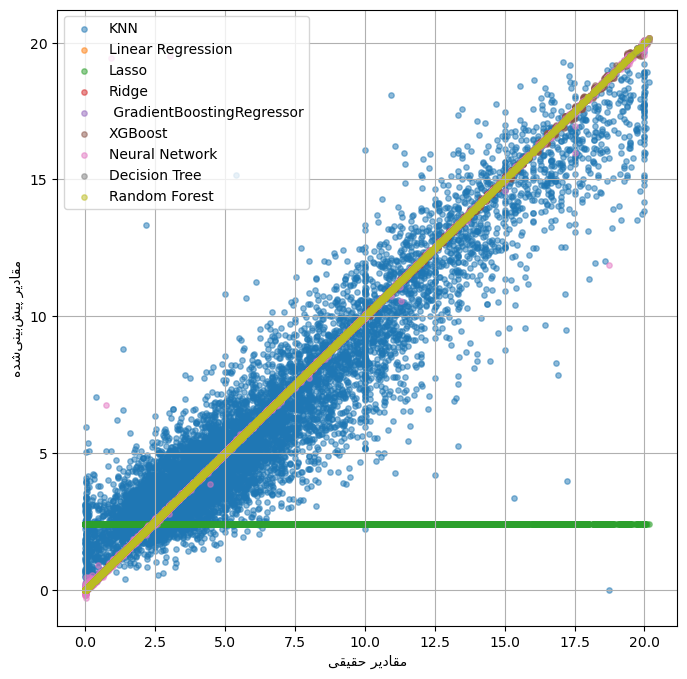

In [47]:
plt.figure(figsize=(8,8))

y_test_f = y_test
for name, model in models.items():    
   # y_test_f = y_test_t if name in ['Decision Tree', 'Random Forest'] else y_test
    
    plt.scatter(
        y_test_f, 
        model[2], 
        alpha=0.5, 
        s=15,       # نقطه کوچیک برای کم شدن شلوغی
        label=name
    )

plt.xlabel(text_fa('مقادیر حقیقی'))
plt.ylabel(text_fa('مقادیر پیش‌بینی‌شده'))
plt.legend()
plt.grid(True)
plt.show()
    
# max_val = max( y_test_f.max(), max([pred.max() for pred in models.values[2]]))
# min_val = min(y_test_f.min(), min([pred.min() for pred in models.values[2]]))
# plt.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2)

# plt.xlabel(text_fa('مقادیر حقیقی'))
# plt.ylabel(text_fa('مقادیر پیش‌بینی‌شده'))
# plt.title(text_fa('مقادیر حقیقی/ مقادیر پیش‌بینی‌شده برای همه مدل‌ها '))
# plt.legend()
# plt.grid(True)
# plt.show()

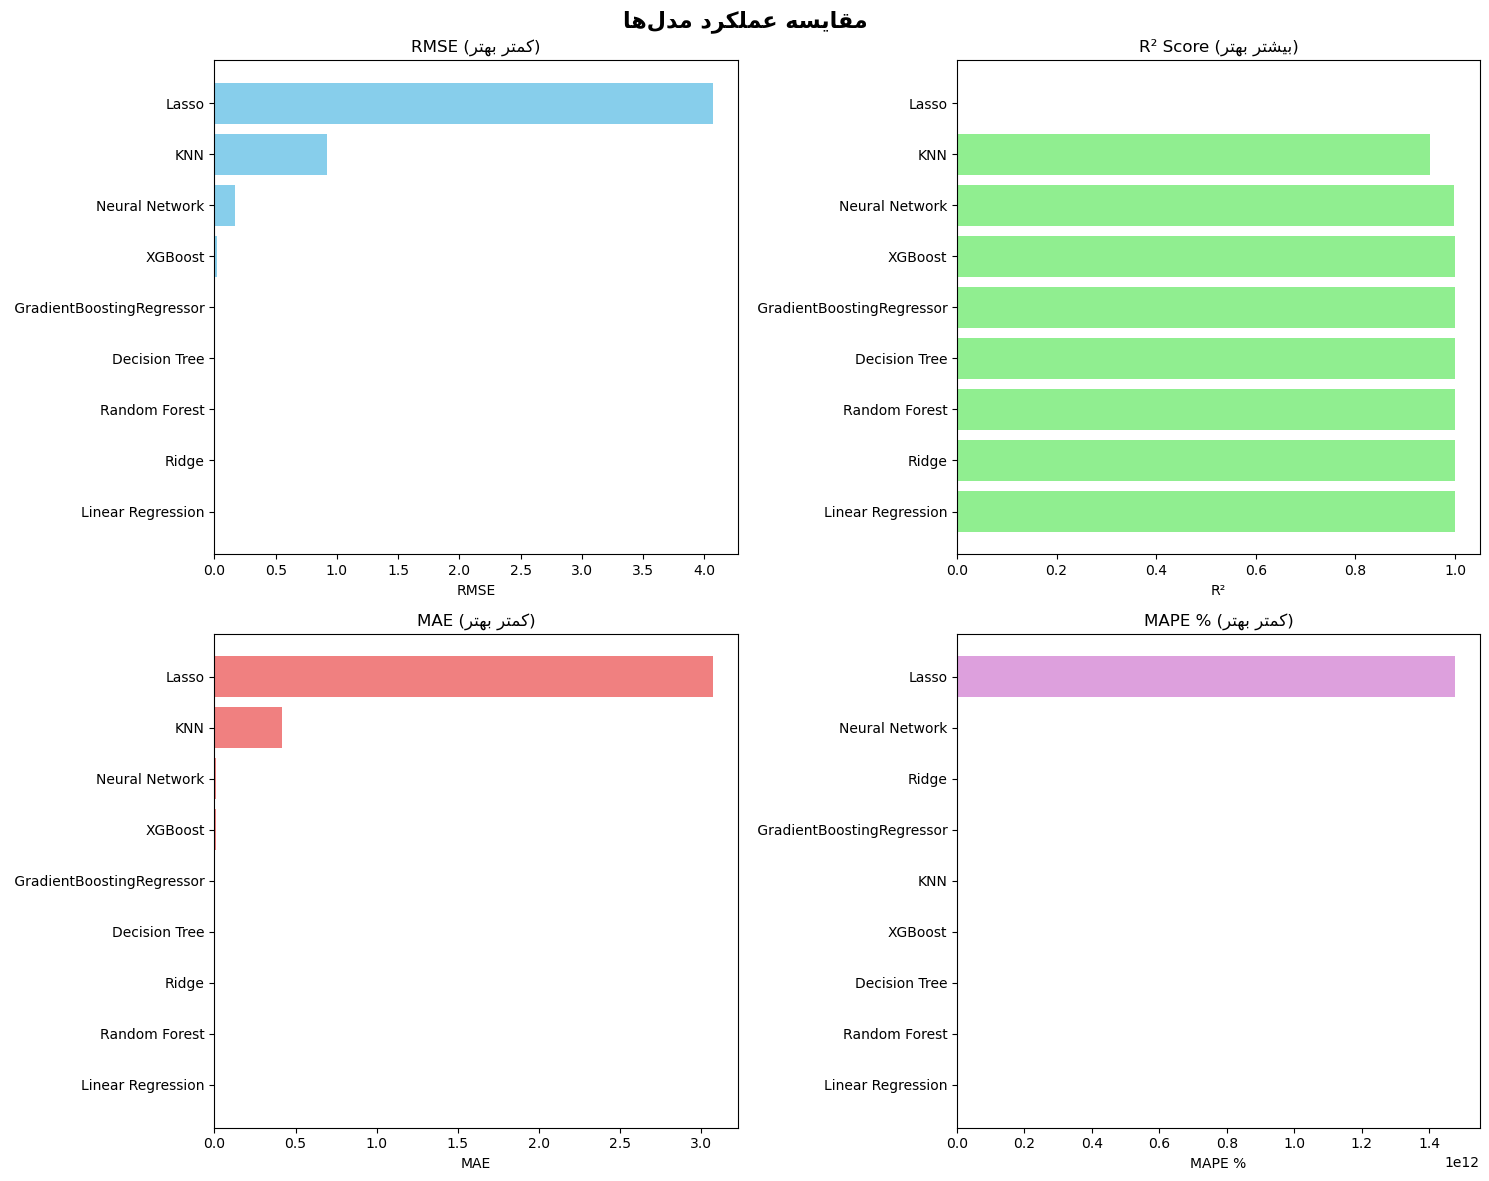

In [38]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle(text_fa('مقایسه عملکرد مدل‌ها'), fontsize=16, fontweight='bold')


evaluation_results_df = pd.DataFrame(evaluation_results).T

rmse_sorted = evaluation_results_df['RMSE'].sort_values()
axes[0, 0].barh(rmse_sorted.index, rmse_sorted.values, color='skyblue')
axes[0, 0].set_title(text_fa('RMSE (کمتر بهتر)'))
axes[0, 0].set_xlabel('RMSE')

r2_sorted = evaluation_results_df['R2'].sort_values(ascending=False)
axes[0, 1].barh(r2_sorted.index, r2_sorted.values, color='lightgreen')
axes[0, 1].set_title(text_fa('R² Score (بیشتر بهتر)'))
axes[0, 1].set_xlabel('R²')

mae_sorted = evaluation_results_df['MAE'].sort_values()
axes[1, 0].barh(mae_sorted.index, mae_sorted.values, color='lightcoral')
axes[1, 0].set_title(text_fa('MAE (کمتر بهتر)'))
axes[1, 0].set_xlabel('MAE')

mape_sorted = evaluation_results_df['MAPE'].sort_values()
axes[1, 1].barh(mape_sorted.index, mape_sorted.values, color='plum')
axes[1, 1].set_title(text_fa('MAPE % (کمتر بهتر)'))
axes[1, 1].set_xlabel('MAPE %')

plt.tight_layout()
plt.show()

# Choose Best Model

| Metric                                    | Goal             | Notes                                                     |
| ----------------------------------------- | ---------------- | --------------------------------------------------------- |
| **MAE** (Mean Absolute Error)             | Lower is better  | Average absolute error, same unit as target (e.g., price) |
| **RMSE** (Root Mean Squared Error)        | Lower is better  | Penalizes large errors more than MAE                      |
| **MAPE** (Mean Absolute Percentage Error) | Lower is better  | Percentage error, good for relative comparison            |
| **R²** (Coefficient of Determination)     | Higher is better | Explains how much variance is captured by the model       |


In [45]:
evaluation_results_df['MAE_rank'] = evaluation_results_df['MAE'].rank(ascending=True)
evaluation_results_df['RMSE_rank'] = evaluation_results_df['RMSE'].rank(ascending=True)
evaluation_results_df['MAPE_rank'] = evaluation_results_df['MAPE'].rank(ascending=True)

evaluation_results_df['R2_rank'] = evaluation_results_df['R2'].rank(ascending=False)

evaluation_results_df['Overall_rank'] = evaluation_results_df[['MAE_rank','RMSE_rank','MAPE_rank','R2_rank']].sum(axis=1)

# Best model = lowest Overall_rank
best_model_name = evaluation_results_df['Overall_rank'].idxmin()
best_model_score = evaluation_results_df.loc[best_model_name, 'Overall_rank']

print(text_fa('بهترین مدل برای داده‌های املاک: ') )
print (best_model_name)


 :ﮎﻼﻣﺍ ﯼﺎﻫﻩﺩﺍﺩ ﯼﺍﺮﺑ ﻝﺪﻣ ﻦﯾﺮﺘﻬﺑ
Linear Regression


<a id = "rf"></a>
<h1  style="color:blue; font-family:Nazanin;" dir="rtl">تحلیل نتایج: </h1>



<p style="font-family:Nazanin; font-size:140%; text-align:right;" dir="rtl">
   با استفاده از مدل‌سازی انجام شده، نتایج به دست آمده را با توجه به رابطه قیمت و ویژگی‌ها ملک، به سه دست گران (over-value)، مناسب (normal) و ارزان (under-value) تقسیم کنید.
</p>

In [49]:
y_test_f = y_test
# if best_model_name in ['Decision Tree', 'Random Forest']:
#     y_test_f = y_test_t
y_pred = models[best_model_name][2]

df_analys = pd.DataFrame({
    'Actual': y_test_f,
    'Predicted': y_pred
})

df_analys['Residual'] = df_analys['Actual'] - df_analys['Predicted']
residual_std = df_analys['Residual'].std()

df_analys['Category'] = df_analys.apply(
    lambda r: 'Under-value' if r['Residual'] > residual_std 
    else 'over-value' if r['Residual'] < -residual_std
    else 'Normal',
    axis = 1
)
print(df_analys['Category'].value_counts())


Category
Normal        25121
over-value       71
Name: count, dtype: int64


# Plot Residual and Thresholds

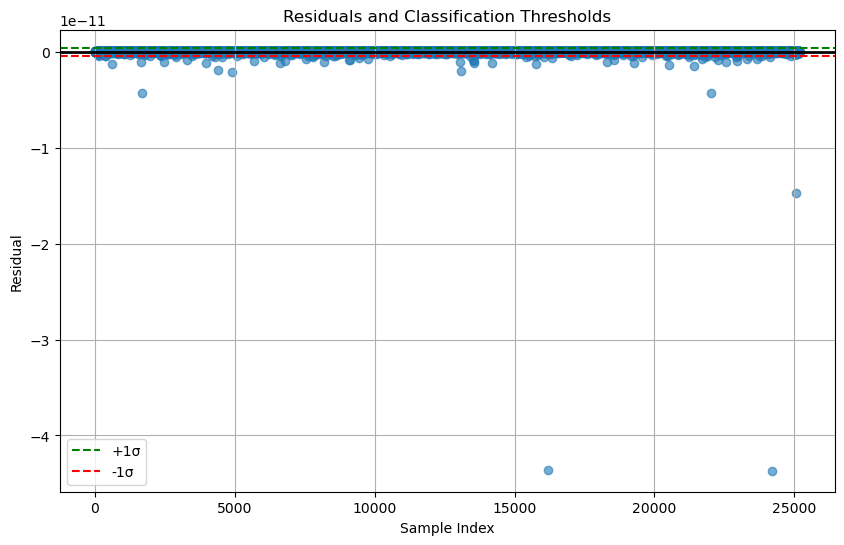

In [50]:
plt.figure(figsize=(10,6))
plt.scatter(range(len(df_analys)), df_analys['Residual'], alpha=0.6)

plt.axhline(residual_std, color='green', linestyle='--', label='+1σ')
plt.axhline(-residual_std, color='red', linestyle='--', label='-1σ')
plt.axhline(0, color='black', linewidth=2)

plt.title("Residuals and Classification Thresholds")
plt.xlabel("Sample Index")
plt.ylabel("Residual")
plt.legend()
plt.grid(True)
plt.show()
